In [1]:
def calc_normal_stress(force_N, area_mm2):
    # 단위: 힘(N), 면적(mm^2) -> 응력(MPa)
    stress_mpa = force_N / area_mm2
    return stress_mpa

print(f"수직 응력: {calc_normal_stress(10000, 50):.2f} MPa")


수직 응력: 200.00 MPa


In [2]:
def calc_thermal_stress(E_GPa, alpha, delta_T):
    # E_GPa를 MPa로 변환하여 계산
    stress_mpa = (E_GPa * 1000) * alpha * delta_T
    return stress_mpa

print(f"열응력: {calc_thermal_stress(210, 1.2e-5, 50):.2f} MPa")


열응력: 126.00 MPa


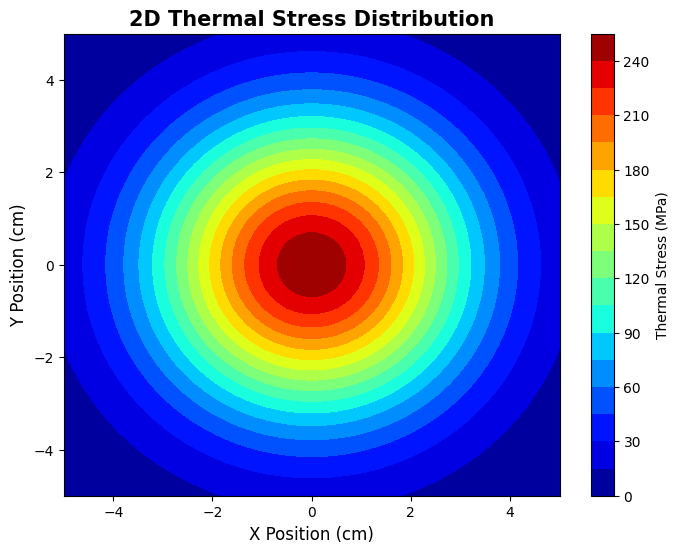

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 2D 평면 격자 생성 (10cm x 10cm 평판)
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)

# 2. 중심부가 뜨거운 온도 분포 설정 (가우스 분포 활용)
# 중심부 최대 100도 상승, 외곽으로 갈수록 온도가 낮아짐
delta_T = 100 * np.exp(-(X**2 + Y**2) / 10)

# 3. 열응력 계산 (완전 구속 상태 가정)
E = 210000        # 강철의 탄성계수 (MPa)
alpha = 1.2e-5    # 열팽창계수 (1/°C)
thermal_stress = E * alpha * delta_T  # 발생하는 압축 열응력 (MPa)

# 4. 2D 열응력 분포 컬러 맵 시각화
plt.figure(figsize=(8, 6))
cp = plt.contourf(X, Y, thermal_stress, cmap='jet', levels=20)
plt.colorbar(cp, label='Thermal Stress (MPa)')

plt.title('2D Thermal Stress Distribution', fontsize=15, fontweight='bold')
plt.xlabel('X Position (cm)', fontsize=12)
plt.ylabel('Y Position (cm)', fontsize=12)
plt.grid(False)
plt.show()


In [5]:
import math
def calc_torsion(torque_Nm, diameter_mm):
    r_m = (diameter_mm / 2) / 1000
    # 원형 축의 극관성모멘트 J (m^4)
    J = (math.pi / 2) * (r_m ** 4)
    tau_Pa = (torque_Nm * r_m) / J
    return tau_Pa / 1e6  # MPa로 변환

print(f"비틀림 응력: {calc_torsion(500, 30):.2f} MPa")

비틀림 응력: 94.31 MPa


In [6]:
def calc_bending_stress(moment_Nm, y_mm, I_mm4):
# 단위를 N, mm 기준으로 통일하여 MPa 도출
    moment_Nmm = moment_Nm * 1000
    stress_mpa = (moment_Nmm * y_mm) / I_mm4
    return stress_mpa

print(f"굽힘 응력: {calc_bending_stress(1000, 25, 416000):.2f} MPa")


굽힘 응력: 60.10 MPa
